In [1]:
import sys
sys.executable


'c:\\Users\\Lenovo\\Desktop\\GitHub\\venv\\Scripts\\python.exe'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)


In [3]:
import sqlite3

db_path = "frn50k_data.db"
conn = sqlite3.connect(db_path)

train_data = pd.read_sql("SELECT * FROM train_data", conn)
eval_data = pd.read_sql("SELECT * FROM eval_data", conn)

train_data.head()


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,hours_sale,stock_hour6_22_cnt,hours_stock_status,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level
0,4,832,2,29,76,60,596,2024-04-10 00:00:00.000000,0.7,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...,4,b'\x01\x00\x00\x00\x00\x00\x00\x00\x01\x00\x00...,1.000,0,0,1.5019,17.91,77.27,2.08
1,0,154,6,4,53,58,578,2024-06-02 00:00:00.000000,1.7,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...,9,b'\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...,0.908,1,1,1.7640,23.60,69.71,1.52
2,0,555,6,8,29,115,99,2024-04-06 00:00:00.000000,1.6,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...,5,b'\x01\x00\x00\x00\x00\x00\x00\x00\x01\x00\x00...,0.725,1,1,2.8081,17.55,78.55,1.43
3,0,309,6,4,28,180,118,2024-06-22 00:00:00.000000,1.1,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...,0,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...,1.000,1,0,7.9425,27.22,82.12,1.44
4,16,546,2,31,79,230,549,2024-05-02 00:00:00.000000,1.3,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...,0,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...,1.000,1,0,1.8981,21.43,73.30,1.55


In [4]:
print("Train shape:", train_data.shape)
print("Eval shape:", eval_data.shape)

train_data.info()


Train shape: (450000, 19)
Eval shape: (35000, 19)
<class 'pandas.DataFrame'>
RangeIndex: 450000 entries, 0 to 449999
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   city_id              450000 non-null  int64  
 1   store_id             450000 non-null  int64  
 2   management_group_id  450000 non-null  int64  
 3   first_category_id    450000 non-null  int64  
 4   second_category_id   450000 non-null  int64  
 5   third_category_id    450000 non-null  int64  
 6   product_id           450000 non-null  int64  
 7   dt                   450000 non-null  str    
 8   sale_amount          450000 non-null  float64
 9   hours_sale           450000 non-null  object 
 10  stock_hour6_22_cnt   450000 non-null  int64  
 11  hours_stock_status   450000 non-null  object 
 12  discount             450000 non-null  float64
 13  holiday_flag         450000 non-null  int64  
 14  activity_flag        450000 n

In [5]:
train_data.columns

Index(['city_id', 'store_id', 'management_group_id', 'first_category_id',
       'second_category_id', 'third_category_id', 'product_id', 'dt',
       'sale_amount', 'hours_sale', 'stock_hour6_22_cnt', 'hours_stock_status',
       'discount', 'holiday_flag', 'activity_flag', 'precpt',
       'avg_temperature', 'avg_humidity', 'avg_wind_level'],
      dtype='str')

In [6]:
train_data.nunique()


city_id                    18
store_id                  898
management_group_id         7
first_category_id          32
second_category_id         84
third_category_id         233
product_id                865
dt                         90
sale_amount               707
hours_sale             279112
stock_hour6_22_cnt         17
hours_stock_status       4581
discount                 1543
holiday_flag                2
activity_flag               2
precpt                  38984
avg_temperature          1572
avg_humidity             4727
avg_wind_level            247
dtype: int64

In [7]:
train_data.describe()

,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,sale_amount,stock_hour6_22_cnt,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level
count,450000.000000,450000.000000,450000.000000,450000.000000,450000.000000,450000.000000,450000.000000,450000.000000,450000.000000,450000.000000,450000.000000,450000.000000,450000.000000,450000.000000,450000.000000,450000.000000
mean,4.976667,409.909322,4.623782,15.215922,44.777642,116.263631,389.931796,0.994182,3.192433,0.911378,0.344627,0.378416,3.691029,22.270331,74.427241,1.725004
std,6.094184,248.834866,1.960029,8.969400,22.343602,57.486704,263.286246,1.384504,4.601373,0.127860,0.475247,0.484993,3.686628,3.590614,10.128691,0.385096
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.880000,27.350000,0.970000
25%,0.000000,195.000000,4.000000,5.000000,28.000000,77.000000,135.000000,0.400000,0.000000,0.851000,0.000000,0.000000,1.427300,19.370000,71.610000,1.450000
50%,0.000000,397.000000,6.000000,16.000000,38.000000,111.000000,363.000000,0.700000,0.000000,0.990000,0.000000,0.000000,2.296300,22.490000,76.350000,1.640000
75%,12.000000,599.000000,6.000000,21.000000,66.000000,167.000000,633.000000,1.100000,6.000000,1.000000,1.000000,1.000000,4.442900,25.390000,80.690000,1.950000
max,17.000000,897.000000,6.000000,31.000000,83.000000,232.000000,864.000000,40.400000,16.000000,1.042000,1.000000,1.000000,34.582800,30.880000,92.680000,3.850000


In [8]:
train_data.isnull().sum()

city_id                0
store_id               0
management_group_id    0
first_category_id      0
second_category_id     0
third_category_id      0
product_id             0
dt                     0
sale_amount            0
hours_sale             0
stock_hour6_22_cnt     0
hours_stock_status     0
discount               0
holiday_flag           0
activity_flag          0
precpt                 0
avg_temperature        0
avg_humidity           0
avg_wind_level         0
dtype: int64

In [9]:
train_data["dt"] = pd.to_datetime(train_data["dt"])

train_data["dt"].min(), train_data["dt"].max()


(Timestamp('2024-03-28 00:00:00'), Timestamp('2024-06-25 00:00:00'))

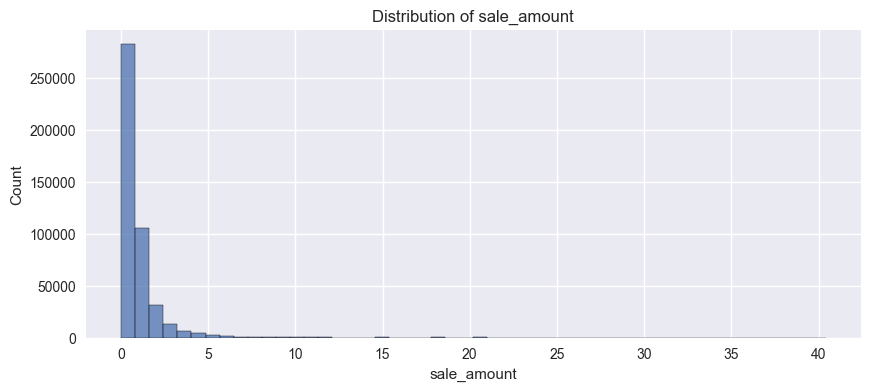

In [10]:
plt.figure(figsize=(10,4))
sns.histplot(train_data["sale_amount"], bins=50)
plt.title("Distribution of sale_amount")
plt.show()


In [11]:
zero_ratio = (train_data["sale_amount"] == 0).mean()
zero_ratio


np.float64(0.044546666666666665)

In [12]:
train_data["hour"] = train_data["hours_sale"]
train_data["weekday"] = train_data["dt"].dt.dayofweek
train_data["weekday_name"] = train_data["dt"].dt.day_name()

train_data[["dt", "hour", "weekday_name"]].head()


,dt,hour,weekday_name
0,2024-04-10,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...,Wednesday
1,2024-06-02,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...,Sunday
2,2024-04-06,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...,Saturday
3,2024-06-22,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...,Saturday
4,2024-05-02,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...,Thursday


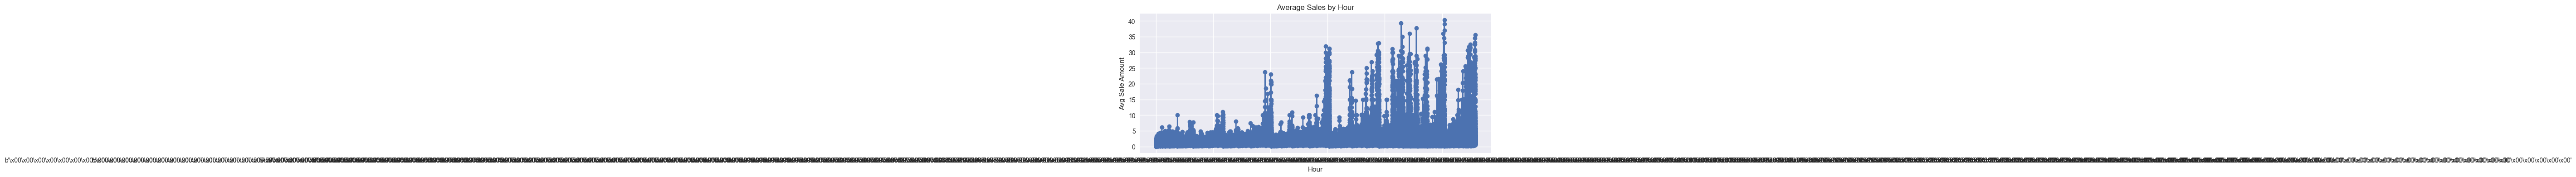

In [13]:
hourly_sales = train_data.groupby("hour")["sale_amount"].mean()

plt.figure(figsize=(10,4))
hourly_sales.plot(marker="o")
plt.title("Average Sales by Hour")
plt.xlabel("Hour")
plt.ylabel("Avg Sale Amount")
plt.grid(True)
plt.show()


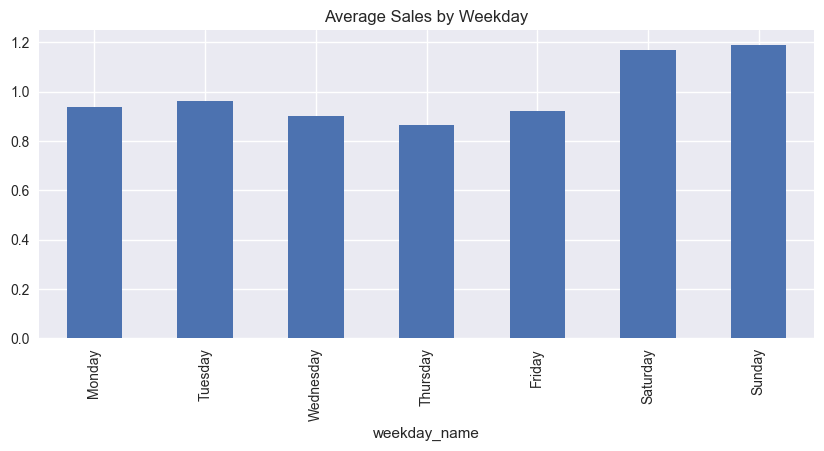

In [14]:
weekly_sales = train_data.groupby("weekday_name")["sale_amount"].mean()
weekly_sales = weekly_sales.reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
)

weekly_sales.plot(kind="bar", figsize=(10,4))
plt.title("Average Sales by Weekday")
plt.show()


In [15]:
train_data["is_stockout"] = train_data["hours_stock_status"] == 0

train_data.groupby("is_stockout")["sale_amount"].mean()


is_stockout
False    0.994182
Name: sale_amount, dtype: float64

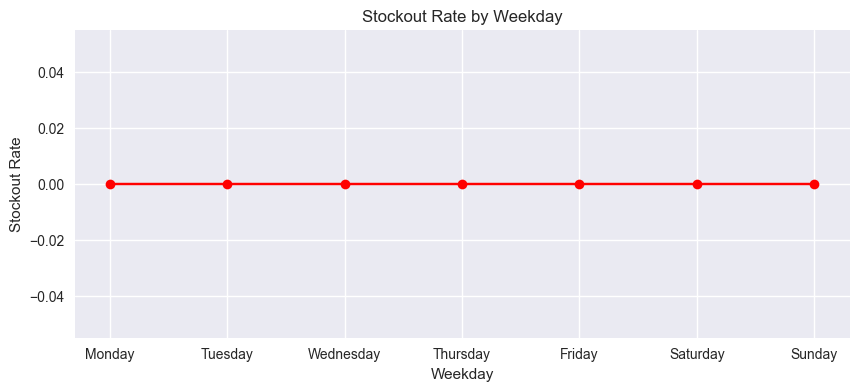

In [16]:

weekly_stockout = train_data.groupby("weekday_name")["is_stockout"].mean()

ordered_days = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekly_stockout = weekly_stockout.reindex(ordered_days)

plt.figure(figsize=(10,4))
weekly_stockout.plot(marker="o", color="red")
plt.title("Stockout Rate by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Stockout Rate")
plt.grid(True)
plt.show()



In [17]:
avg_sales_in_stock = train_data.loc[~train_data["is_stockout"], "sale_amount"].mean()
avg_sales_stockout = train_data.loc[train_data["is_stockout"], "sale_amount"].mean()

avg_sales_in_stock, avg_sales_stockout


(np.float64(0.994181788888889), nan)

In [26]:
train_data["day_of_week"] = train_data["dt"].dt.day_name()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11176\331216388.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


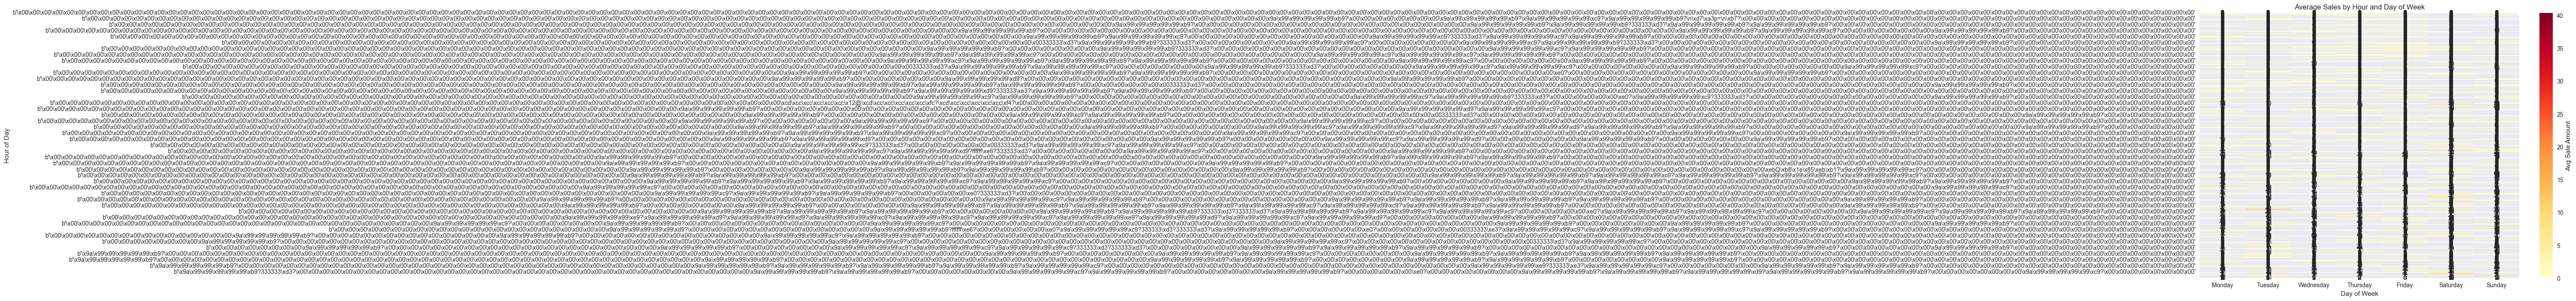

In [27]:

sales_heatmap_data = train_data.pivot_table(
    values="sale_amount", 
    index="hour", 
    columns="weekday_name", 
    aggfunc="mean"
)

ordered_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sales_heatmap_data = sales_heatmap_data[ordered_days]

plt.figure(figsize=(12, 8))
sns.heatmap(sales_heatmap_data, annot=True, fmt=".0f", cmap="YlOrRd", cbar_kws={"label": "Avg Sale Amount"})
plt.title("Average Sales by Hour and Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Hour of Day")
plt.tight_layout()
plt.show()
